# Vivino Analysis:

*...Initialising...*
  
✅ Setting up imports and connecting to the database

  
*...Thinking...*
  
The most important factors are *price and the average user rating* of a wine. Let's start by looking at those.   
💡 Wines can have several vintages. A vintage belongs to a single wine. think of a vintage as "Year YYYY edition" of a given wine.

- 📊 Looking at price distributions of all wines: Huge spread, starting around 20, going as high as 10k. (Nothing Under 20€ except for small bottles of 375 ml).  
     
- 📊 Looking at the distribution of wine ratings, we can see a largely normal distribution. However, the dataset ratings begin at 4.1 going up to 4.9. This is an artifact of the dataset itself.  
  
- 📊 Looking at average price per rating, we get the expected result: higher price for higher ratings. The highest rating (4.9) dips, but that's a small sample artifact.  
  
- 📊 Looking at average number of ratings per rating (with average price for reference). That is to say: for the all the 4.4 rated vintages, what is the average number of time the rating was given? We would expect a downward slope: as we've seen, higher rated wines are more expensive, therefore, theyy should also be less often rated, since they more difficult to obtain.     
However, we get something interesting: the 4.5 rating is the forgotten group.  


- Some observations:  
    - 47 wines and 246 vintages have a rating of 4.7 and above. It's a small set. 


### Highlighted Top 10: [10 Selected wines](#selected-top-10)
How should we select 10 wines amongs 2000 of them? Here is how I approached the problem.
We want to showcase 10 wines, *to increase sales*. Price is a big factor here.
I decided to create a balancede selection for several price categories


### Marketing Budget: [Marketing budget](#marketing-budget)
US, France, and Italy. They have the most users, all three have a very high number of wines and wineries.


## Table of Contents
- [Initialising](#initialising)
- [Thinking](#thinking)
- [Highlight 10 wines](#highlight-10-wines)

## Data Cleaning

Some text here.

## Visualization

More text here.


### Initialising

In [34]:
## Imports
import sqlite3

# For charting:
import pandas as pd 
import matplotlib.pyplot as plt

# paths
from pathlib import Path





In [35]:
# Connecting to db and loading the database
#db_path = "../data/vivino.db"
%load_ext sql
%sql sqlite:///../data/vivino.db

connexion = sqlite3.connect("../data/vivino.db")
cursor = connexion.cursor()


## Usefull info lines: 
# %sql?
# %sqlcmd tables
# %sqlcmd columns -t countries

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [36]:
## Syntax ref for later : 
# This syntax works: 

with open("../queries/cheapest_wines.sql", encoding="utf-8") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)
#df

#df.plot(kind="box", y="price_euros", figsize=(6, 6), sharex=False, legend=False)
#df.plot(kind="box", y="price_euros", ylim=(0,1000), figsize=(6, 6), sharex=False, legend=False)
#df.plot(subplots=True, kind="box", layout=(2, 1), figsize=(6, 12), y="price_euros", ylim=(0,1000),  legend=False)

## This works too, but the results aren't well displayed: no column names
#results = cursor.execute(query).fetchall()
#results
#print(results)


### Thinking:

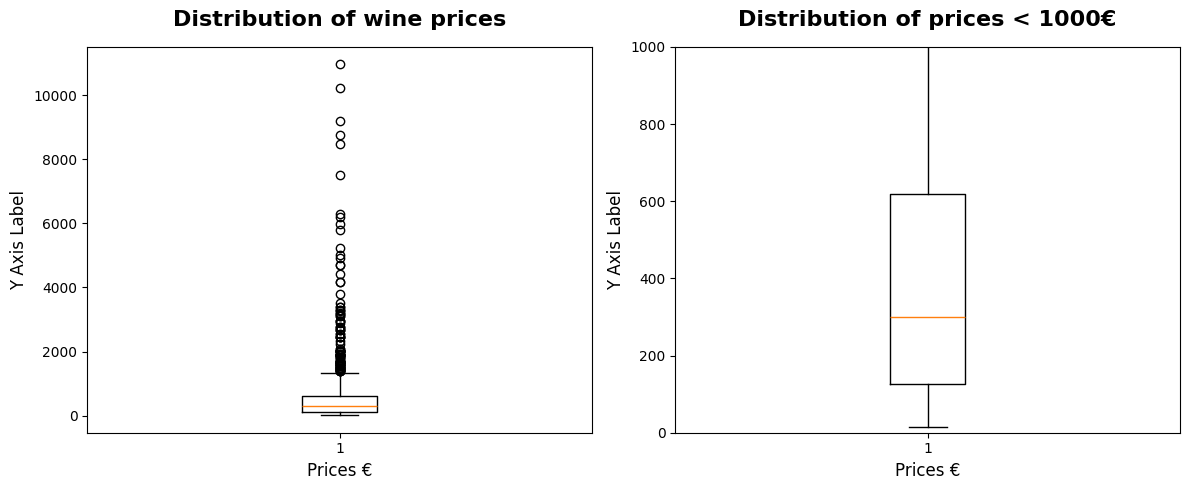

In [37]:
## Visualizing wine prices
## Data
with open("../queries/cheapest_wines.sql", encoding="utf-8") as f:
    query = f.read()
df = pd.read_sql_query(query, connexion)

## Plotting:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5),  gridspec_kw={"width_ratios": [1, 1]})  # left is 2x wider than right

axes[0].boxplot(df["price_euros"], vert=True)          
    
axes[1].boxplot(df["price_euros"], vert=True)              
axes[1].set_ylim(0,1000)

# Title and Labels
axes[0].set_title("Distribution of wine prices", fontsize=16, fontweight="bold", pad=15)
axes[0].set_xlabel("Prices €", fontsize=12)
axes[0].set_ylabel("Y Axis Label", fontsize=12)

axes[1].set_title("Distribution of prices < 1000€", fontsize=16, fontweight="bold", pad=15)
axes[1].set_xlabel("Prices €", fontsize=12)
axes[1].set_ylabel("Y Axis Label", fontsize=12)
fig.tight_layout()   
plt.show()

<Axes: title={'center': "'ratings_average' from 'wines'"}, xlabel='ratings_average', ylabel='Count'>

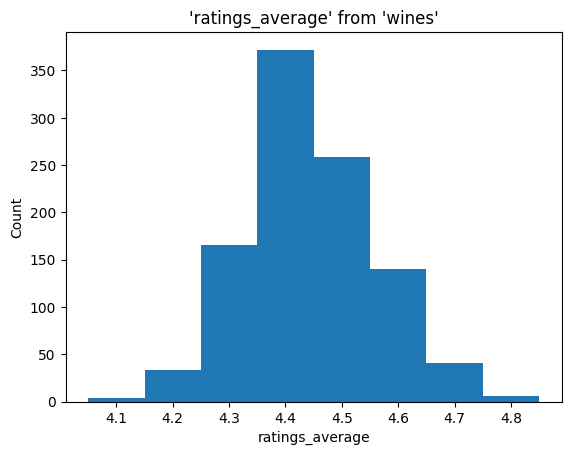

In [38]:
%sqlplot histogram --table wines --column ratings_average --bins 8


<Axes: title={'center': 'Avg price per rating for vintages'}, xlabel='ratings_average'>

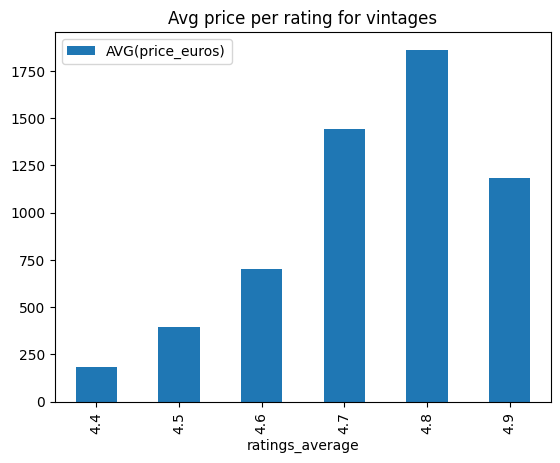

In [39]:
## Average price per rating for vintages
with open("../queries/avg_price_by_rating.sql", encoding="utf-8") as f:
    query = f.read()
    
df = pd.read_sql_query(query, connexion)
df.plot.bar(x="ratings_average", y="AVG(price_euros)", title="Avg price per rating for vintages")

Running query in 'sqlite:///../data/vivino.db'

<Axes: xlabel='ratings_average'>

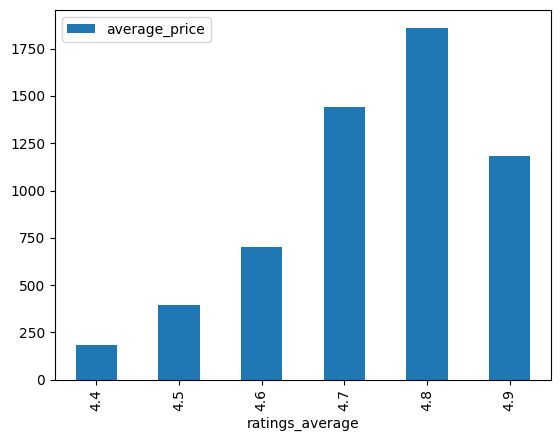

In [40]:
## Average Prices by ratings : charted
result = %sql SELECT ratings_average, AVG(price_euros) AS average_price FROM vintages WHERE ratings_average > 4.0 GROUP BY ratings_average ORDER BY ratings_average ASC
df = result.DataFrame()
df.plot.bar(x='ratings_average', y='average_price')

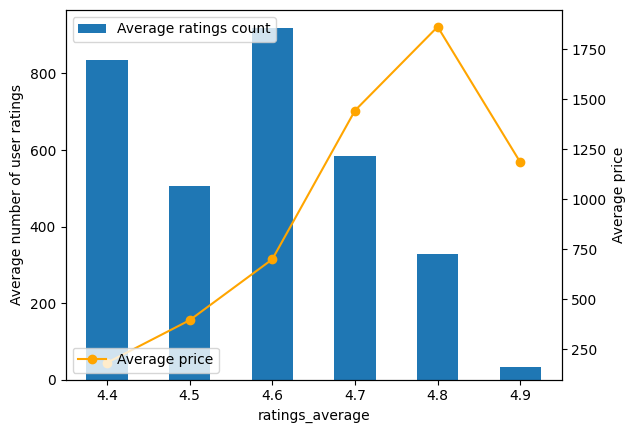

In [ ]:
## Plotting average number of ratings per rating (and showing average prices for each rating)

with open("../queries/average_rating_count_by_rating.sql", encoding="utf-8") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)

plot_df = df.set_index("ratings_average")

ax = plot_df["average_ratings_count"].plot.bar(label="Average ratings count")
ax2 = ax.twinx()

ax2.plot(range(len(plot_df)), plot_df["average_price"], color="orange", marker="o", label="Average price")

ax.set_ylabel("Average number of user ratings")
ax2.set_ylabel("Average price")
ax.set_xticklabels(plot_df.index, rotation=0)

ax.legend(loc="upper left")
ax2.legend(loc="lower left")

# y_label="average ratings count",
# legend="average_price"

### Selected Top 10.  
How should we select 10 wines amongs 2000 of them? Here is how I approached the problem.
We want to showcase 10 wines, *to increase sales*. Price is a big factor here.
I decided to create a balanced selection for several price categories, making sure to have a variety of origins, some reds, some whites. I also exculded any vintage having less than 200 user ratings, to preserve statistical significance through wisdom of the crowd.

5X Great deal: (<30€) (2 white, 3 reds)
3X Excellent: (<50€) 4.5 (1 white, 2 reds)
2X Amazing: under 100
1X Luxury : A few exceptionnal bottles for their price

Improvements:
We could create a feaute that merges average rating and price, into a balanced bang_for_buck ratings. 
Take the ratings divide by adjusted price. Boom. Normalise maybe,

**Great Deals:**
| Wine ID | Vintage ID | Rating | Country        | Region                    | Price        | RED/WHITE | Name |
|---------|------------|--------|----------------|---------------------------|--------------|-----------|------|
| 6741558 | 160094800  | 4.5    | Italie         | Primitivo di Manduria *** | 24.0         | RED       | Name |
| 3783366 | 152008500  | 4.4    | Moldavie       | Moldova                   | 46.77 (1.5L) | WHITE     | Name |
| 16504   | 159319855  | 4.4    | Argentine      | Mendoza                   | 26.0         | RED       | Name |
| 1627830 | 146295008  | 4.4    | Afrique du Sud | Stellenbosch              | 27.0         | RED       | Name |
| 2246136 | 156124899  | 4.4    | Chili          | Maipo Valley              | 30           | WHITE     | Name |


**Excellent:**
| Wine ID | Vintage ID | Rating | Country  | Region                | Price | RED/WHITE | Name |
|---------|------------|--------|----------|-----------------------|-------|-----------|------|
| 1468452 | 127578652  | 4.5    | Moldavie | Moldova               | 31.0  | White     | Name |
| 11890   | 150263185  | 4.5    | Italie   | Primitivo di Manduria | 32.0  | Red       | Name |
| 7830543 | 163184376  | 4.5    | France   | Côtes-du-Rhône        | 35.0  | Red       | Name |


**Amazing**
| Wine ID | Vintage ID | Rating | Country | Region                              | Price | RED/WHITE | Name |
|---------|------------|--------|---------|-------------------------------------|-------|-----------|------|
| 1168085 | 25822713   | 4.6    | Italie  | Amarone della Valpolicella Classico | 75.0  | red       | Name |
| 66284   | 159338927  | 4.6    | US      | Napa Valley                         | 89.0  | Red       | Name |


**Luxury: A few exceptionnal bottles:**
| Wine ID | Vintage ID | Rating | Country | Region                 | Price | RED/WHITE | Name |
|---------|------------|--------|---------|------------------------|-------|-----------|------|
| 1175427 | 156110733  | 4.7    | Espagne | Ribera del Duero       | 180.0 | red       | Name |
| 81836   | 131862469  | 4.8    | Italie  | Brunello di Montalcino | 379.0 | Red       | Name |



In [73]:
## New top 10
with open("../queries/top_ten.sql", encoding="utf-8") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)
df

,wine_id,vintage_id,country_name,region_name,adjusted_price,ratings_average,name,ratings_count,price_euros,tannin,price_discounted_from,bottle_volume_ml,fizziness
0,81836,131862469,Italie,Brunello di Montalcino,379.0,4.8,Casanova di Neri Cerretalto Brunello di Montal...,175,379.00,3.650135,None,750,NaN
1,84065,2890763,Italie,Amarone della Valpolicella Classico,425.0,4.8,Quintarelli Giuseppe Amarone della Valpolicell...,444,425.00,2.311430,None,750,NaN
2,1194532,2423072,Italie,Veneto,555.0,4.8,Quintarelli Giuseppe Veneto Alzero Cabernet 2009,208,555.00,2.936496,None,750,NaN
3,82203,127064316,Italie,Barolo,705.0,4.8,Giacomo Conterno Barolo Cascina Francia 2016,214,705.00,4.331374,None,750,NaN
4,8023,103459705,États-Unis,Napa Valley,745.0,4.8,Colgin IX Estate Red 2016,131,745.00,3.635063,None,750,NaN
5,1153863,14207721,France,Sauternes,811.0,4.8,Château d'Yquem Sauternes 2015,763,811.25,NaN,None,750,NaN
6,1274124,150679517,France,Montrachet Grand Cru,812.0,4.8,Joseph Drouhin Montrachet Grand Cru Marquis de...,137,811.80,NaN,None,750,NaN
7,1153863,150313476,France,Sauternes,833.0,4.8,Château d'Yquem Sauternes 2017,334,832.50,NaN,None,750,NaN
8,1611255,14187320,États-Unis,Rutherford,1559.0,4.8,Scarecrow Cabernet Sauvignon 2015,243,1558.75,3.393993,None,750,NaN
9,1655970,2641965,France,Pauillac,1686.0,4.8,Château Latour Grand Vin Pauillac (Premier Gra...,920,1686.25,4.140877,None,750,NaN


### Highlight 10 wines
For prices, careful with discounts

What wines should we highlight?
- Very good wines : > 4.6 average score
- not very well known : under 500 user ratings, but above 100. 
- Have a mix of red and whites
- Variety of countries

Selection: 10 bottles for every budget: (+1 for dreaming...)
5X Great deal: 4.4 (2 white, 3 reds)
3X Excellent: 4.5
2X Amazing: 4.6
1X Luxury : 4.7 and up


**WINNERS SO FAR** There are too much, I'll make an executive decision later

| Wine ID | Vintage ID | Rating | Country   | Region                | Price           | RED/WHITE       | Name                                                                              |
|---------|------------|--------|-----------|-----------------------|-----------------|-----------------|-----------------------------------------------------------------------------------|
| 1129440 | 160148272  | 4.4    | Italy     | Primitivo di Manduria | 23(re-adjusted) | Red             | Luccarelli Old Vines Primitivo di Manduria 2019                                   |
| 3783366 | 152008500  | 4.4    | Moldavie  | Moldova               | 46.77 (1.5l)    | White           | Gitana Saperavi 2017                                                              |
| 16504   | 159319855  | 4.4    | Argentina | Mendoza               | 25.99           | Red             | Rutini Malbec 2019                                                                |
| 2246136 | 156124899  | 4.4    | Chili     | Maipo Valley          | 29.95           | White           | El Principal Memorias 2018                                                        |
| 5364329 | 163053458  | 4.4    | Italy     | Abruzzo               | 23.9            | Red             | Farnese Cinque Autoctoni Collection Limited Release 2020                          |
| 6741558 | 160094800  | 4.5    | Italy     | Primitivo di Manduria | 23.95           | Red             | Vigneti del Salento Vigne Vecchie Gold Series Leggenda Primitivo di Manduria 2019 |
| 1468452 | 127578652  | 4.5    | Moldavie  | Moldova               | 61.29 (1.5L)    | White           | Gitana Lupi Rezerva 2016                                                          |
| 7830543 | 163184376  | 4.5    | France    | Côtes-du-Rhône        | 34.95           | Red             | Château de Gourdon Terrasse à l'Ombre Côtes du Rhône 2018                         |
| 18323   | 2590138    | 4.6    | Chili     | Colchagua Valley      | 89.0            | Red             | Casa Silva Altura 2012                                                            |
| 1301256 | 8738731    | 4.6    | France    | Champagne             | 199.0           | White-Sparkling | Deutz Amour de Deutz Millésimé Brut Champagne 2011                                |
| 1175427 | 86137513   | 4.7    | Espagne   | Ribera del Duero      | 202.2           | Red             | ** Vega Sicilia Valbuena 5º 2016                                                  |
| 5194    | 159405688  | 4.7    | US        | Rutherford            | 260             | Red             | ** Quintessa Rutherford 2019                                                      |
| 84065   | 2890763    | 4.8    | Italy     | ?                     | 425             | Red             | ** Quintarelli Giuseppe Amarone della Valpolicella Classico 2013                  |







Joining some tables: 
I have my doubts that these are different wine id is different, and but vintage is different, but bodega can be the same
I should include some different tasting notes.
i need to adjust price by volume

**REMARKS**
12 wines have a discount; not a big deal.

Trying to see the wines that appear more than once:


In [75]:
%%sql
SELECT wines.id, wines.name, vintages.wine_id, count(wines.id)
FROM wines
JOIN vintages on wines.id = vintages.wine_id
GROUP BY wines.id
HAVING count(wines.id) >=2 -- AND count(wines.id) < 7 
ORDER BY count(wines.id) DESC
LIMIT 10

Running query in 'sqlite:///../data/vivino.db'

id,name,wine_id,count(wines.id)
22447,Bolgheri Superiore,22447,26
5078,Sassicaia,5078,25
2446729,Toscana,2446729,24
3908,Pauillac (Premier Grand Cru Classé),3908,19
1558589,Brunello di Montalcino,1558589,17
82698,Brunello di Montalcino Riserva,82698,16
66104,Barbaresco,66104,16
1652,Tignanello,1652,16
1152755,Pessac-Léognan (Premier Grand Cru Classé),1152755,15
1127795,Château Margaux (Premier Grand Cru Classé),1127795,14


### Marketing budget
We have a marketing budget, where should we spend it?
US, France, and Italy. They have the most users, all three have a very high number of wines and wineries.



In [78]:
with open("../queries/user_count_by_country.sql", encoding="utf-8") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)
df


,code,name,regions_count,users_count,wines_count,wineries_count
0,us,États-Unis,362,12273684,204060,28145
1,fr,France,1306,5973301,422503,67553
2,it,Italie,563,4270717,274658,42399
3,de,Allemagne,236,2549989,164533,13643
4,es,Espagne,152,2264396,102662,18026
5,ch,Suisse,73,1601799,33656,3849
6,pt,Portugal,93,1123535,39847,5834
7,au,Australie,120,1022965,90954,13946
8,ar,Argentine,41,629532,36121,5339
9,cl,Chili,41,326757,41191,5785


### Winery awards
- We would like to give awards to the best wineries. Come up with 3 relevant ones. Which wineries should we choose and why? Be creative ;)

Ok, now we could use the bang for buck feature.
find wineries who have great bang for buck

That's with price
We could do just the best wineries overall, no price weights.

Also, limit to wineries that have more than 5 wines.
Best Winery id's:  42463, 7892, 223950, 13261, 4009, 40453, 3060, 19992, 52856, 55648






### Region awards wold be a nice addition to that


In [113]:
## Winery awards
with open("../queries/best_wineries.sql", encoding="utf-8") as f:
    query = f.read()

df = pd.read_sql_query(query, connexion)
df
#best_wineries = df["winery_id"].to_list()
#print(best_wineries)

,winery_id,country,region,bang_for_buck,avg_price,bottle_volume_ml
0,42463,Italie,Primitivo di Manduria,0.187500,24.0,750
1,7892,Italie,Abruzzo,0.183333,24.0,750
2,223950,Italie,Primitivo di Manduria,0.179592,24.0,750
3,13261,Italie,Barbera d'Asti,0.176000,33.0,1000
4,4009,Argentine,Mendoza,0.169231,26.0,750
...,...,...,...,...,...,...
378,1523,France,Châteauneuf-du-Pape,0.001669,2789.0,750
379,3286,France,Champagne Grand Cru 'Le Mesnil-sur-Oger',0.001650,2868.0,750
380,12630,France,Pomerol,0.000790,5948.0,750
381,11610,France,Romanée-Saint-Vivant Grand Cru,0.000510,9142.0,750


In [ ]:
%%sql
SELECT 
winery_id,
countries.name AS country, 
regions.name AS region,
--round((price_euros / bottle_volume_ml)*750) AS adjusted_price,
(AVG(vintages.ratings_average) / AVG(round((price_euros / bottle_volume_ml)*750))) AS bang_for_buck,
round(AVG(vintages.price_euros)) AS avg_price, 
vintages.bottle_volume_ml
FROM vintages
JOIN wines ON wines.id = vintages.wine_id
JOIN regions ON regions.id =  wines.region_id
JOIN countries ON countries.code = regions.country_code
WHERE  vintages.ratings_count > 100 
GROUP BY wines.winery_id
ORDER BY bang_for_buck DESC

Running query in 'sqlite:///../data/vivino.db'

winery_id,country,region,bang_for_buck,avg_price,bottle_volume_ml
42463,Italie,Primitivo di Manduria,0.1875,24.0,750
7892,Italie,Abruzzo,0.18333333333333335,24.0,750
223950,Italie,Primitivo di Manduria,0.1795918367346939,24.0,750
13261,Italie,Barbera d'Asti,0.17600000000000002,33.0,1000
4009,Argentine,Mendoza,0.16923076923076924,26.0,750
40453,Italie,Marche,0.16603773584905662,27.0,750
3060,Afrique du Sud,Stellenbosch,0.16296296296296298,27.0,750
19992,Italie,Puglia,0.16181818181818183,28.0,750
52856,France,Sauternes,0.15714285714285717,14.0,375
55648,Italie,Primitivo di Manduria,0.156140350877193,44.0,1500
